In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
lstm = pd.read_csv('lstm_fold_metrics.csv')

In [4]:
lstm

,fold,train_accuracy,train_auc,train_f1,val_accuracy,val_auc,val_f1,model_path
0,1,0.998594,0.999936,0.998594,0.997395,0.999373,0.997392,./lstm_fold_1
1,2,0.999373,0.999953,0.999373,0.995879,0.998978,0.995889,./lstm_fold_2
2,3,0.998987,0.999953,0.998987,0.997409,0.999443,0.997409,./lstm_fold_3
3,4,0.998622,0.999946,0.998622,0.996830,0.999325,0.996826,./lstm_fold_4
4,5,0.999170,0.999958,0.999170,0.996582,0.999060,0.996574,./lstm_fold_5


In [6]:
BERT_train = {
    'acc':[0.9939,0.9942,0.9948,0.9941,0.9942],
    'auc':[0.9983,0.9983,0.9984,0.9983,0.9983],
    'f1':[0.9939,0.9942,0.9940,0.9941,0.9942]
}

SVC_train = {
    'acc':[0.9921,0.9926,0.9904,0.9948,0.9927],
    'auc':[0.9993,0.9993,0.9990,0.9997,0.9994],
    'f1':[0.9920,0.9925,0.9904,0.9948,0.9927]
}

RFC_train = {
    'acc':[1,1,1,1,0.9999],
    'auc':[1,1,1,1,1],
    'f1':[1,1,1,1,0.9999]
}

LSTM_train = {
    'acc':lstm['train_accuracy'].values,
    'auc':lstm['train_auc'].values,
    'f1':lstm['train_f1'].values
}

BERT_test = {
    'acc':[0.9955,0.9959,0.9961,0.9958,0.9955],
    'auc':[0.9984,0.9985,0.9984,0.9985,0.9984],
    'f1':[0.9955,0.9960,0.9967,0.9958,0.9955]
}

SVC_test = {
    'acc':[0.9915,0.9923,0.9896,0.9945,0.9921],
    'auc':[0.9993,0.9992,0.9989,0.9997,0.9992],
    'f1':[0.9914,0.9922,0.9895,0.9945,0.9921]
}

RFC_test = {
    'acc':[0.9988,0.9989,0.9987,0.9988,0.9988],
    'auc':[0.9999,0.9999,0.9999,0.9999,0.9999],
    'f1':[0.9988,0.9989,0.9986,0.9988,0.9988]
}

LSTM_test = {
    'acc':lstm['val_accuracy'].values,
    'auc':lstm['val_auc'].values,
    'f1':lstm['val_f1'].values
}

In [7]:
def stats_dict(d):
    return {k: {"mean": np.mean(v), "std": np.std(v, ddof=1)} for k,v in d.items()}

In [8]:
bert_train_stats = stats_dict(BERT_train)
svc_train_stats = stats_dict(SVC_train)
rfc_train_stats = stats_dict(RFC_train)
lstm_train_stats = stats_dict(LSTM_train)

bert_test_stats = stats_dict(BERT_test)
svc_test_stats = stats_dict(SVC_test)
rfc_test_stats = stats_dict(RFC_test)
lstm_test_stats = stats_dict(LSTM_test)

In [12]:
stats_train_df = pd.DataFrame({
    "Model": ["BERT","SVC","RFC","LSTM"],
    "ACC_mean":[bert_train_stats["acc"]["mean"], svc_train_stats["acc"]["mean"], rfc_train_stats["acc"]["mean"], lstm_train_stats["acc"]["mean"]],
    "ACC_std":[bert_train_stats["acc"]["std"], svc_train_stats["acc"]["std"], rfc_train_stats["acc"]["std"],lstm_train_stats["acc"]["std"]],
    "AUC_mean":[bert_train_stats["auc"]["mean"], svc_train_stats["auc"]["mean"], rfc_train_stats["auc"]["mean"],lstm_train_stats["auc"]["mean"]],
    "AUC_std":[bert_train_stats["auc"]["std"], svc_train_stats["auc"]["std"], rfc_train_stats["auc"]["std"],lstm_train_stats["auc"]["std"]],
    "F1_mean":[bert_train_stats["f1"]["mean"], svc_train_stats["f1"]["mean"], rfc_train_stats["f1"]["mean"],lstm_train_stats["f1"]["mean"]],
    "F1_std":[bert_train_stats["f1"]["std"], svc_train_stats["f1"]["std"], rfc_train_stats["f1"]["std"],lstm_train_stats["f1"]["std"]]
})

stats_test_df = pd.DataFrame({
    "Model": ["BERT","SVC","RFC","LSTM"],
    "ACC_mean":[bert_test_stats["acc"]["mean"], svc_test_stats["acc"]["mean"], rfc_test_stats["acc"]["mean"],lstm_test_stats["acc"]["mean"]],
    "ACC_std":[bert_test_stats["acc"]["std"], svc_test_stats["acc"]["std"], rfc_test_stats["acc"]["std"],lstm_test_stats["acc"]["std"]],
    "AUC_mean":[bert_test_stats["auc"]["mean"], svc_test_stats["auc"]["mean"], rfc_test_stats["auc"]["mean"],lstm_test_stats["auc"]["mean"]],
    "AUC_std":[bert_test_stats["auc"]["std"], svc_test_stats["auc"]["std"], rfc_test_stats["auc"]["std"],lstm_test_stats["auc"]["std"]],
    "F1_mean":[bert_test_stats["f1"]["mean"], svc_test_stats["f1"]["mean"], rfc_test_stats["f1"]["mean"],lstm_test_stats["f1"]["mean"]],
    "F1_std":[bert_test_stats["f1"]["std"], svc_test_stats["f1"]["std"], rfc_test_stats["f1"]["std"],lstm_test_stats["f1"]["std"]],
})

In [15]:
SVR_train_blogs = pd.read_csv('svr_blogs_train_metrics.csv')
SVR_test_blogs = pd.read_csv('svr_blogs_test_metrics.csv')

KNN_train_blogs = pd.read_csv('knn_blogs_train_metrics.csv')
KNN_test_blogs = pd.read_csv('knn_blogs_test_metrics.csv')

RFR_train_blogs = pd.read_csv('rfr_blogs_train_metrics.csv')
RFR_test_blogs = pd.read_csv('rfr_blogs_test_metrics.csv')

ENET_train_blogs = pd.read_csv('enet_blogs_train_metrics.csv')
ENET_test_blogs = pd.read_csv('enet_blogs_test_metrics.csv')

SVR_train_news = pd.read_csv('svr_news_train_metrics.csv')
SVR_test_news = pd.read_csv('svr_news_test_metrics.csv')

KNN_train_news = pd.read_csv('knn_news_train_metrics.csv')
KNN_test_news = pd.read_csv('knn_news_test_metrics.csv')

RFR_train_news = pd.read_csv('rfr_news_train_metrics.csv')
RFR_test_news = pd.read_csv('rfr_news_test_metrics.csv')

ENET_train_news = pd.read_csv('enet_news_train_metrics.csv')
ENET_test_news = pd.read_csv('enet_news_test_metrics.csv')

SVR_train_socmed = pd.read_csv('svr_socmed_train_metrics.csv')
SVR_test_socmed = pd.read_csv('svr_socmed_test_metrics.csv')

KNN_train_socmed = pd.read_csv('knn_socmed_train_metrics.csv')
KNN_test_socmed = pd.read_csv('knn_socmed_test_metrics.csv')

RFR_train_socmed = pd.read_csv('rfr_socmed_train_metrics.csv')
RFR_test_socmed = pd.read_csv('rfr_socmed_test_metrics.csv')

ENET_train_socmed = pd.read_csv('enet_socmed_train_metrics.csv')
ENET_test_socmed = pd.read_csv('enet_socmed_test_metrics.csv')

In [17]:
SVR_train_blogs_stats = stats_dict(SVR_train_blogs)
SVR_test_blogs_stats  = stats_dict(SVR_test_blogs)

KNN_train_blogs_stats = stats_dict(KNN_train_blogs)
KNN_test_blogs_stats  = stats_dict(KNN_test_blogs)

RFR_train_blogs_stats = stats_dict(RFR_train_blogs)
RFR_test_blogs_stats  = stats_dict(RFR_test_blogs)

ENET_train_blogs_stats = stats_dict(ENET_train_blogs)
ENET_test_blogs_stats  = stats_dict(ENET_test_blogs)

SVR_train_socmed_stats = stats_dict(SVR_train_socmed)
SVR_test_socmed_stats  = stats_dict(SVR_test_socmed)

KNN_train_socmed_stats = stats_dict(KNN_train_socmed)
KNN_test_socmed_stats  = stats_dict(KNN_test_socmed)

RFR_train_socmed_stats = stats_dict(RFR_train_socmed)
RFR_test_socmed_stats  = stats_dict(RFR_test_socmed)

ENET_train_socmed_stats = stats_dict(ENET_train_socmed)
ENET_test_socmed_stats  = stats_dict(ENET_test_socmed)

SVR_train_news_stats = stats_dict(SVR_train_news)
SVR_test_news_stats  = stats_dict(SVR_test_news)

KNN_train_news_stats = stats_dict(KNN_train_news)
KNN_test_news_stats  = stats_dict(KNN_test_news)

RFR_train_news_stats = stats_dict(RFR_train_news)
RFR_test_news_stats  = stats_dict(RFR_test_news)

ENET_train_news_stats = stats_dict(ENET_train_news)
ENET_test_news_stats  = stats_dict(ENET_test_news)

In [29]:
stats_df_blogs = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_train_blogs_stats["MAE"]["mean"], KNN_train_blogs_stats["MAE"]["mean"], RFR_train_blogs_stats["MAE"]["mean"],ENET_train_blogs_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_train_blogs_stats["MAE"]["std"],  KNN_train_blogs_stats["MAE"]["std"],  RFR_train_blogs_stats["MAE"]["std"],ENET_train_blogs_stats["MAE"]["std"]],
    "RMSE_mean": [SVR_train_blogs_stats["RMSE"]["mean"], KNN_train_blogs_stats["RMSE"]["mean"], RFR_train_blogs_stats["RMSE"]["mean"],ENET_train_blogs_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_train_blogs_stats["RMSE"]["std"],  KNN_train_blogs_stats["RMSE"]["std"],  RFR_train_blogs_stats["RMSE"]["std"],ENET_train_blogs_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_train_blogs_stats["R2"]["mean"],  KNN_train_blogs_stats["R2"]["mean"],  RFR_train_blogs_stats["R2"]["mean"],ENET_train_blogs_stats["R2"]["mean"]],
    "R2_std":    [SVR_train_blogs_stats["R2"]["std"],   KNN_train_blogs_stats["R2"]["std"],   RFR_train_blogs_stats["R2"]["std"],ENET_train_blogs_stats["R2"]["std"]],
})


stats_df_socmed = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_train_socmed_stats["MAE"]["mean"], KNN_train_socmed_stats["MAE"]["mean"], RFR_train_socmed_stats["MAE"]["mean"],ENET_train_socmed_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_train_socmed_stats["MAE"]["std"],  KNN_train_socmed_stats["MAE"]["std"],  RFR_train_socmed_stats["MAE"]["std"],ENET_train_socmed_stats["MAE"]["std"],],
    "RMSE_mean": [SVR_train_socmed_stats["RMSE"]["mean"], KNN_train_socmed_stats["RMSE"]["mean"], RFR_train_socmed_stats["RMSE"]["mean"],ENET_train_socmed_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_train_socmed_stats["RMSE"]["std"],  KNN_train_socmed_stats["RMSE"]["std"],  RFR_train_socmed_stats["RMSE"]["std"],ENET_train_socmed_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_train_socmed_stats["R2"]["mean"],  KNN_train_socmed_stats["R2"]["mean"],  RFR_train_socmed_stats["R2"]["mean"],ENET_train_socmed_stats["R2"]["mean"]],
    "R2_std":    [SVR_train_socmed_stats["R2"]["std"],   KNN_train_socmed_stats["R2"]["std"],   RFR_train_socmed_stats["R2"]["std"],ENET_train_socmed_stats["R2"]["std"]],
})

stats_df_news = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_train_news_stats["MAE"]["mean"], KNN_train_news_stats["MAE"]["mean"], RFR_train_news_stats["MAE"]["mean"],ENET_train_news_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_train_news_stats["MAE"]["std"],  KNN_train_news_stats["MAE"]["std"],  RFR_train_news_stats["MAE"]["std"],ENET_train_news_stats["MAE"]["std"]],
    "RMSE_mean": [SVR_train_news_stats["RMSE"]["mean"], KNN_train_news_stats["RMSE"]["mean"], RFR_train_news_stats["RMSE"]["mean"],ENET_train_news_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_train_news_stats["RMSE"]["std"],  KNN_train_news_stats["RMSE"]["std"],  RFR_train_news_stats["RMSE"]["std"],ENET_train_news_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_train_news_stats["R2"]["mean"],  KNN_train_news_stats["R2"]["mean"],  RFR_train_news_stats["R2"]["mean"],ENET_train_news_stats["R2"]["mean"]],
    "R2_std":    [SVR_train_news_stats["R2"]["std"],   KNN_train_news_stats["R2"]["std"],   RFR_train_news_stats["R2"]["std"],ENET_train_news_stats["R2"]["std"]],
})

stats_df_blogs_test = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_test_blogs_stats["MAE"]["mean"], KNN_test_blogs_stats["MAE"]["mean"], RFR_test_blogs_stats["MAE"]["mean"], ENET_test_blogs_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_test_blogs_stats["MAE"]["std"],  KNN_test_blogs_stats["MAE"]["std"],  RFR_test_blogs_stats["MAE"]["std"], ENET_test_blogs_stats["MAE"]["std"]],
    "RMSE_mean": [SVR_test_blogs_stats["RMSE"]["mean"], KNN_test_blogs_stats["RMSE"]["mean"], RFR_test_blogs_stats["RMSE"]["mean"], ENET_test_blogs_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_test_blogs_stats["RMSE"]["std"],  KNN_test_blogs_stats["RMSE"]["std"],  RFR_test_blogs_stats["RMSE"]["std"], ENET_test_blogs_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_test_blogs_stats["R2"]["mean"],  KNN_test_blogs_stats["R2"]["mean"],  RFR_test_blogs_stats["R2"]["mean"], ENET_test_blogs_stats["R2"]["mean"]],
    "R2_std":    [SVR_test_blogs_stats["R2"]["std"],   KNN_test_blogs_stats["R2"]["std"],   RFR_test_blogs_stats["R2"]["std"], ENET_test_blogs_stats["R2"]["std"]],
})


stats_df_socmed_test = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_test_socmed_stats["MAE"]["mean"], KNN_test_socmed_stats["MAE"]["mean"], RFR_test_socmed_stats["MAE"]["mean"],ENET_test_socmed_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_test_socmed_stats["MAE"]["std"],  KNN_test_socmed_stats["MAE"]["std"],  RFR_test_socmed_stats["MAE"]["std"],ENET_test_socmed_stats["MAE"]["std"]],
    "RMSE_mean": [SVR_test_socmed_stats["RMSE"]["mean"], KNN_test_socmed_stats["RMSE"]["mean"], RFR_test_socmed_stats["RMSE"]["mean"],ENET_test_socmed_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_test_socmed_stats["RMSE"]["std"],  KNN_test_socmed_stats["RMSE"]["std"],  RFR_test_socmed_stats["RMSE"]["std"],ENET_test_socmed_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_test_socmed_stats["R2"]["mean"],  KNN_test_socmed_stats["R2"]["mean"],  RFR_test_socmed_stats["R2"]["mean"],ENET_test_socmed_stats["R2"]["mean"]],
    "R2_std":    [SVR_test_socmed_stats["R2"]["std"],   KNN_test_socmed_stats["R2"]["std"],   RFR_test_socmed_stats["R2"]["std"],ENET_test_socmed_stats["R2"]["std"]],
})

stats_df_news_test = pd.DataFrame({
    "Model": ["SVR", "KNN", "RFR","ENET"],
    "MAE_mean":  [SVR_test_news_stats["MAE"]["mean"], KNN_test_news_stats["MAE"]["mean"], RFR_test_news_stats["MAE"]["mean"],ENET_test_news_stats["MAE"]["mean"]],
    "MAE_std":   [SVR_test_news_stats["MAE"]["std"],  KNN_test_news_stats["MAE"]["std"],  RFR_test_news_stats["MAE"]["std"],ENET_test_news_stats["MAE"]["std"]],
    "RMSE_mean": [SVR_test_news_stats["RMSE"]["mean"], KNN_test_news_stats["RMSE"]["mean"], RFR_test_news_stats["RMSE"]["mean"],ENET_test_news_stats["RMSE"]["mean"]],
    "RMSE_std":  [SVR_test_news_stats["RMSE"]["std"],  KNN_test_news_stats["RMSE"]["std"],  RFR_test_news_stats["RMSE"]["std"],ENET_test_news_stats["RMSE"]["std"]],
    "R2_mean":   [SVR_test_news_stats["R2"]["mean"],  KNN_test_news_stats["R2"]["mean"],  RFR_test_news_stats["R2"]["mean"],ENET_test_news_stats["R2"]["mean"]],
    "R2_std":    [SVR_test_news_stats["R2"]["std"],   KNN_test_news_stats["R2"]["std"],   RFR_test_news_stats["R2"]["std"],ENET_test_news_stats["R2"]["std"]],
})


In [30]:
stats_train_df

,Model,ACC_mean,ACC_std,AUC_mean,AUC_std,F1_mean,F1_std
0,BERT,0.994240,0.000336,0.998320,0.000045,0.994080,0.000130
1,SVC,0.992520,0.001574,0.999340,0.000251,0.992480,0.001580
2,RFC,0.999980,0.000045,1.000000,0.000000,0.999980,0.000045
3,LSTM,0.998949,0.000340,0.999949,0.000009,0.998949,0.000340


In [31]:
stats_test_df

,Model,ACC_mean,ACC_std,AUC_mean,AUC_std,F1_mean,F1_std
0,BERT,0.995760,0.000261,0.998440,0.000055,0.995900,0.000495
1,SVC,0.992000,0.001758,0.999260,0.000288,0.991940,0.001795
2,RFC,0.998800,0.000071,0.999900,0.000000,0.998780,0.000110
3,LSTM,0.996819,0.000636,0.999236,0.000204,0.996818,0.000633


In [32]:
stats_df_blogs_test

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,0.651045,0.319289,0.771972,0.358787,0.984486,0.013295
1,KNN,5.627631,2.055230,7.053134,2.940490,0.029707,0.176364
2,RFR,5.043175,1.754321,6.643299,2.688553,0.106180,0.268872
3,ENET,0.394359,0.216671,0.526974,0.305433,0.994137,0.003924


In [33]:
stats_df_socmed_test

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,1.046499,0.531630,1.217854,0.597773,0.916471,0.150303
1,KNN,8.566694,4.664506,10.864261,5.944377,-0.691978,1.419012
2,RFR,9.842694,6.870838,12.512798,7.774622,-1.740377,3.870663
3,ENET,0.568090,0.190173,0.726791,0.246083,0.984884,0.021947


In [34]:
stats_df_news_test

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,1.210260,0.557988,1.422114,0.737513,0.881598,0.149733
1,KNN,8.272853,4.821442,9.825810,4.618341,-0.933777,0.703712
2,RFR,6.478138,3.979325,8.238721,4.227197,-0.293983,0.478676
3,ENET,0.798657,0.628214,0.984948,0.712636,0.947863,0.097204


In [35]:
stats_df_blogs

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,0.412095,0.058455,0.473428,0.072574,0.995538,0.001521
1,KNN,4.092381,0.597699,5.332294,1.000133,0.446354,0.167640
2,RFR,2.224296,0.325519,3.204776,0.603861,0.790163,0.105527
3,ENET,0.299095,0.107305,0.396203,0.153561,0.997091,0.001112


In [36]:
stats_df_socmed

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,0.510018,0.125615,0.593727,0.126853,0.995723,0.001441
1,KNN,4.677501,0.886638,6.943665,1.371625,0.422295,0.145097
2,RFR,3.075714,0.673306,4.767826,0.980716,0.713652,0.124412
3,ENET,0.317623,0.085823,0.481088,0.130952,0.997314,0.000502


In [37]:
stats_df_news

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR,0.790411,0.357686,0.885454,0.342173,0.994714,0.001657
1,KNN,5.647468,2.505659,8.964697,2.602551,0.450052,0.092580
2,RFR,3.700899,1.750846,5.791855,1.950456,0.771935,0.057158
3,ENET,0.496933,0.272826,0.716370,0.256781,0.996526,0.000905


In [38]:
import pickle
import shap
import pandas as pd

In [39]:
df = pd.read_csv('aggregate_blog.csv')

X = df[['year', 'month_sin', 'month_cos', 'ai_pct_lag1', 'ai_pct_lag2', 'ai_pct_ma3','time_index']]

In [40]:
X_train = df[['year', 'month_sin', 'month_cos', 'ai_pct_lag1', 'ai_pct_lag2', 'ai_pct_ma3','time_index']]

scaler= None
with open('scaler_X_enet_blogs.pkl', "rb") as f: 
    scaler = pickle.load(f)
Xscaled = scaler.transform(X_train)

C:\Users\osten\anaconda3\envs\'DataScience'\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [41]:
Xscaled_df = pd.DataFrame(Xscaled, columns=X_train.columns)

In [42]:
svr = None  
with open('svr_blogs scaled fold 5.pkl', "rb") as f: 
    svr = pickle.load(f)

tree = None  
with open('rfr_blogs scaled fold 5.pkl', "rb") as f: 
    tree = pickle.load(f)

knn = None  
with open('knn_blogs scaled fold 5.pkl', "rb") as f: 
    knn = pickle.load(f)

enet = None  
with open('enet_blogs scaled fold 5.pkl', "rb") as f: 
    enet = pickle.load(f)

In [156]:
explainer = shap.KernelExplainer(svr.predict, Xscaled)
shap_values = explainer.shap_values(Xscaled)

  0%|          | 0/74 [00:00<?, ?it/s]

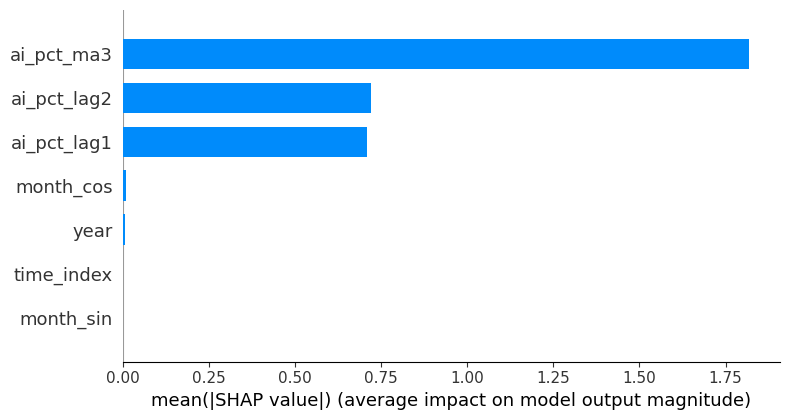

In [155]:
shap.summary_plot(shap_values, Xscaled_df, plot_type="bar") # ENET

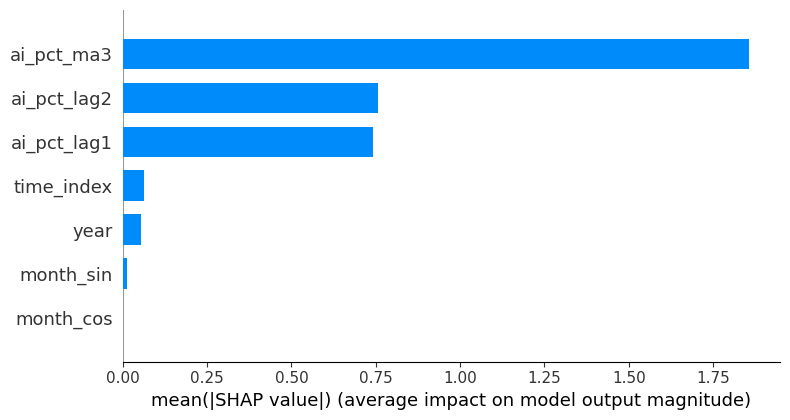

In [157]:
shap.summary_plot(shap_values, Xscaled_df, plot_type="bar") # SVR

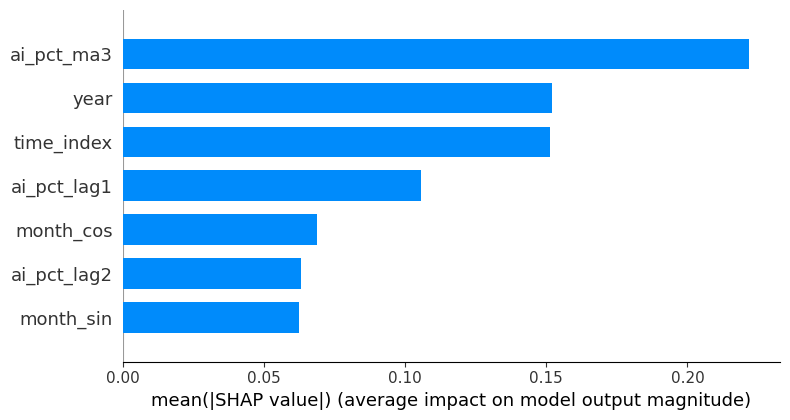

In [47]:
shap.summary_plot(shap_values, Xscaled_df, plot_type="bar") # RFR

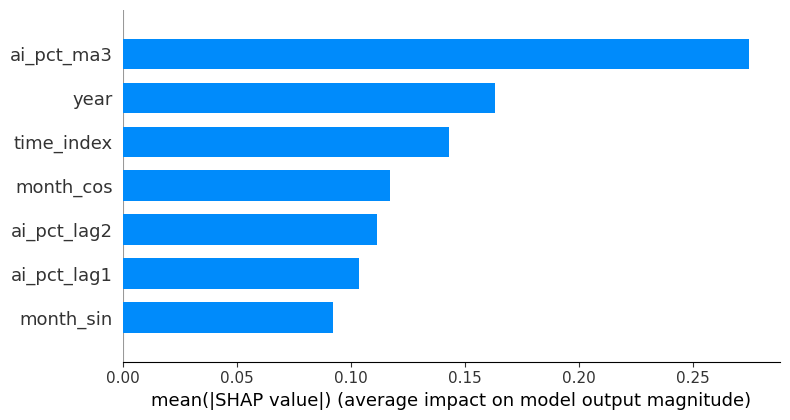

In [49]:
shap.summary_plot(shap_values, Xscaled_df, plot_type="bar") #KNN

# Forecast

In [2]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

In [3]:
df_blogs = pd.read_csv('aggregate_blog.csv')
df_news = pd.read_csv('aggregate_news.csv')
df_socmed = pd.read_csv('aggregated_socmed.csv')

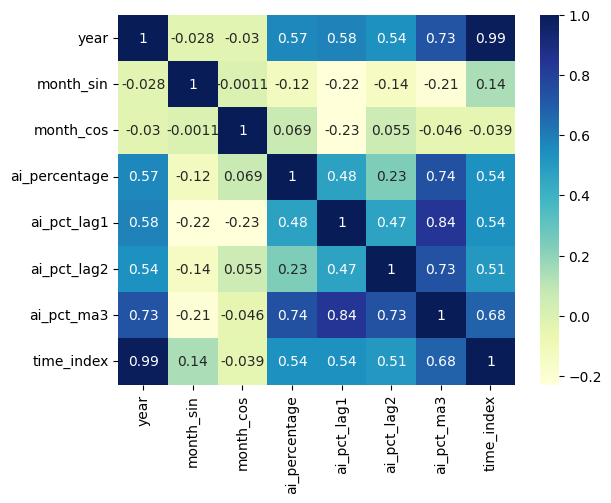

In [5]:
co_mtx = df_blogs.corr(numeric_only=True)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

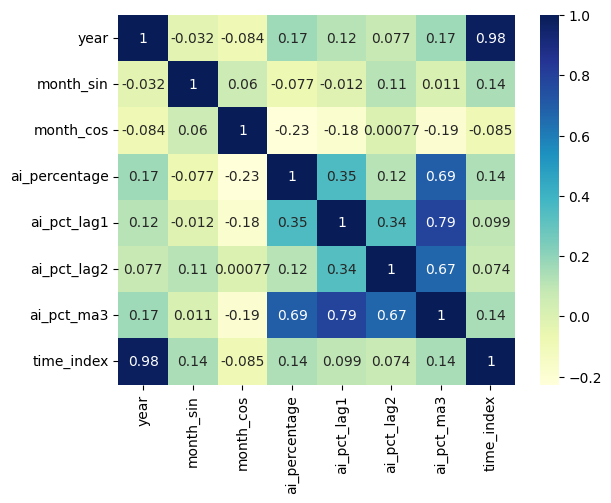

In [6]:
co_mtx = df_news.corr(numeric_only=True)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

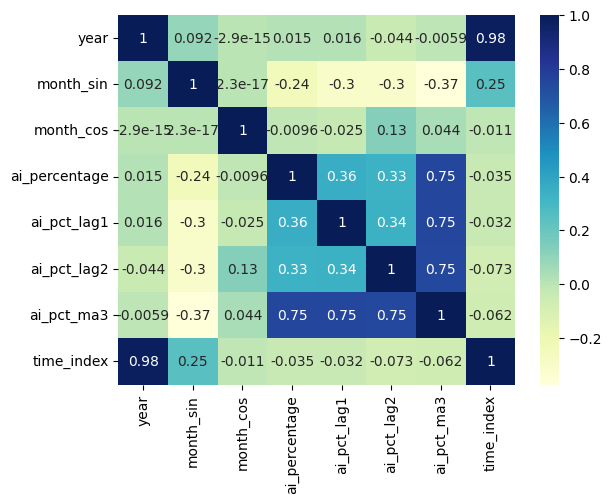

In [7]:
co_mtx = df_socmed.corr(numeric_only=True)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

In [72]:
df_blogs

,year,month_sin,month_cos,ai_percentage,ai_pct_lag1,ai_pct_lag2,ai_pct_ma3,time_index
0,2020,-8.660254e-01,5.000000e-01,10.869565,15.539568,22.222222,16.210452,2
1,2020,-8.660254e-01,-5.000000e-01,11.132438,10.869565,15.539568,12.513857,3
2,2020,-5.000000e-01,8.660254e-01,12.648221,11.132438,10.869565,11.550075,4
3,2020,-5.000000e-01,-8.660254e-01,12.177122,12.648221,11.132438,11.985927,5
4,2020,-2.449294e-16,1.000000e+00,20.881971,12.177122,12.648221,15.235772,6
...,...,...,...,...,...,...,...,...
69,2025,5.000000e-01,-8.660254e-01,25.925926,27.040816,29.922780,27.629841,71
70,2025,5.000000e-01,8.660254e-01,21.942446,25.925926,27.040816,24.969729,72
71,2025,8.660254e-01,5.000000e-01,23.303167,21.942446,25.925926,23.723846,73
72,2025,8.660254e-01,-5.000000e-01,33.895131,23.303167,21.942446,26.380248,74


In [55]:
model = None  
with open('enet_blogs scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)

In [119]:
tree = None  
with open('rfr_blogs scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)

In [73]:
def forecast(model,df, scalerX,scalerY):
    X_train = df[['year', 'month_sin', 'month_cos', 'ai_pct_lag1', 'ai_pct_lag2', 'ai_pct_ma3','time_index']]

    years = np.arange(2026, 2029) 
    months = np.arange(1, 13)    
    
    future_dates = pd.DataFrame([(y, m) for y in years for m in months], columns=['year', 'month'])
    
    future_dates['month_sin'] = np.sin(2 * np.pi * future_dates['month'] / 12)
    future_dates['month_cos'] = np.cos(2 * np.pi * future_dates['month'] / 12)
    
    
    future_dates['time_index'] = np.arange(df['time_index'].max() + 1,
                                           df['time_index'].max() + 1 + len(future_dates))
    
    
    last_values = df['ai_percentage'].iloc[-3:].tolist()  
    
    predictions = []
    
    for idx, row in future_dates.iterrows():
        ai_pct_lag1 = last_values[-1]
        ai_pct_lag2 = last_values[-2]
        ai_pct_ma3  = np.mean(last_values)
        
        X_new_raw = np.array([[row['year'], row['month_sin'], row['month_cos'],
                           ai_pct_lag1, ai_pct_lag2, ai_pct_ma3, row['time_index']]])
        
        X_new_scaled = scalerX.transform(X_new_raw)
    
        y_pred_scaled = model.predict(X_new_scaled)[0]
        
        y_pred_raw = scalerY.inverse_transform([[y_pred_scaled]])[0][0]
        
        predictions.append({
            'year': row['year'],
            'month': row['month'],
            'month_sin': row['month_sin'],
            'month_cos': row['month_cos'],
            'time_index': row['time_index'],
            'ai_percentage': y_pred_raw,
            'ai_pct_lag1': ai_pct_lag1,
            'ai_pct_lag2': ai_pct_lag2,
            'ai_pct_ma3': ai_pct_ma3
        })
        
    
        last_values.append(y_pred_raw)
        last_values.pop(0)  
        
    return pd.DataFrame(predictions)

In [74]:
model = None  
with open('enet_blogs scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_enet_blogs.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_enet_blogs.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
predicted_blogs=forecast(model,df_blogs,scaler_x,scaler_y)

In [75]:
model = None  
with open('enet_news scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_enet_news.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_enet_news.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
predicted_news=forecast(model,df_news,scaler_x,scaler_y)

In [76]:
model = None  
with open('enet_socmed scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_enet_socmed.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_enet_socmed.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
predicted_socmed=forecast(model,df_socmed,scaler_x,scaler_y)

In [120]:
model = None  
with open('rfr_blogs scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_rfr_blogs.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_rfr_blogs.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
non_linear_predicted_blogs=forecast(model,df_blogs,scaler_x,scaler_y)

In [121]:
model = None  
with open('rfr_news scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_rfr_news.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_rfr_news.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
non_linear_predicted_news=forecast(model,df_news,scaler_x,scaler_y)

In [122]:
model = None  
with open('rfr_socmed scaled fold 5.pkl', "rb") as f: 
    model = pickle.load(f)
scaler_x = None
with open('scaler_X_rfr_socmed.pkl', "rb") as f: 
    scaler_x = pickle.load(f)
scaler_y = None
with open('scaler_Y_rfr_socmed.pkl', "rb") as f: 
    scaler_y = pickle.load(f)
non_linear_predicted_socmed=forecast(model,df_socmed,scaler_x,scaler_y)

In [77]:
combined_blogs = pd.concat([df_blogs,predicted_blogs])
combined_news = pd.concat([df_news,predicted_news])
combined_socmed = pd.concat([df_socmed,predicted_socmed])

In [123]:
nl_combined_blogs = pd.concat([df_blogs,non_linear_predicted_blogs])
nl_combined_news = pd.concat([df_news,non_linear_predicted_news])
nl_combined_socmed = pd.concat([df_socmed,non_linear_predicted_socmed])

In [61]:
combined_news

,year,month_sin,month_cos,ai_percentage,ai_pct_lag1,ai_pct_lag2,ai_pct_ma3,time_index,month
0,2020.0,-5.000000e-01,-8.660254e-01,74.539877,69.531250,66.632860,70.234662,2.0,NaN
1,2020.0,-2.449294e-16,1.000000e+00,60.782025,74.539877,69.531250,68.284384,3.0,NaN
2,2020.0,1.224647e-16,-1.000000e+00,98.857143,60.782025,74.539877,78.059682,4.0,NaN
3,2020.0,5.000000e-01,-8.660254e-01,100.000000,98.857143,60.782025,86.546389,5.0,NaN
4,2020.0,5.000000e-01,8.660254e-01,51.404633,100.000000,98.857143,83.420592,6.0,NaN
...,...,...,...,...,...,...,...,...,...
31,2028.0,-8.660254e-01,-5.000000e-01,75.552580,67.740725,78.668263,74.097185,94.0,8.0
32,2028.0,-1.000000e+00,-1.836970e-16,78.249338,75.552580,67.740725,73.987189,95.0,9.0
33,2028.0,-8.660254e-01,5.000000e-01,68.029752,78.249338,75.552580,73.847548,96.0,10.0
34,2028.0,-5.000000e-01,8.660254e-01,75.241646,68.029752,78.249338,73.943890,97.0,11.0


In [124]:
nl_combined_socmed['month'] = np.arctan2(nl_combined_socmed['month_sin'], nl_combined_socmed['month_cos']) * 12 / (2 * np.pi)
nl_combined_socmed['month'] = nl_combined_socmed['month'] % 12
nl_combined_socmed['month'] = nl_combined_socmed['month'].replace(0, 12).astype(int)

nl_combined_news['month'] = np.arctan2(nl_combined_news['month_sin'], nl_combined_news['month_cos']) * 12 / (2 * np.pi)
nl_combined_news['month'] = nl_combined_news['month'] % 12
nl_combined_news['month'] = nl_combined_news['month'].replace(0, 12).astype(int)

nl_combined_blogs['month'] = np.arctan2(nl_combined_blogs['month_sin'], nl_combined_blogs['month_cos']) * 12 / (2 * np.pi)
nl_combined_blogs['month'] = nl_combined_blogs['month'] % 12
nl_combined_blogs['month'] = nl_combined_blogs['month'].replace(0, 12).astype(int)

In [82]:
combined_socmed['month'] = np.arctan2(combined_socmed['month_sin'], combined_socmed['month_cos']) * 12 / (2 * np.pi)
combined_socmed['month'] = combined_socmed['month'] % 12
combined_socmed['month'] = combined_socmed['month'].replace(0, 12).astype(int)

In [81]:
combined_news['month'] = np.arctan2(combined_news['month_sin'], combined_news['month_cos']) * 12 / (2 * np.pi)
combined_news['month'] = combined_news['month'] % 12
combined_news['month'] = combined_news['month'].replace(0, 12).astype(int)

In [80]:
combined_blogs['month'] = np.arctan2(combined_blogs['month_sin'], combined_blogs['month_cos']) * 12 / (2 * np.pi)
combined_blogs['month'] = combined_blogs['month'] % 12
combined_blogs['month'] = combined_blogs['month'].replace(0, 12).astype(int)

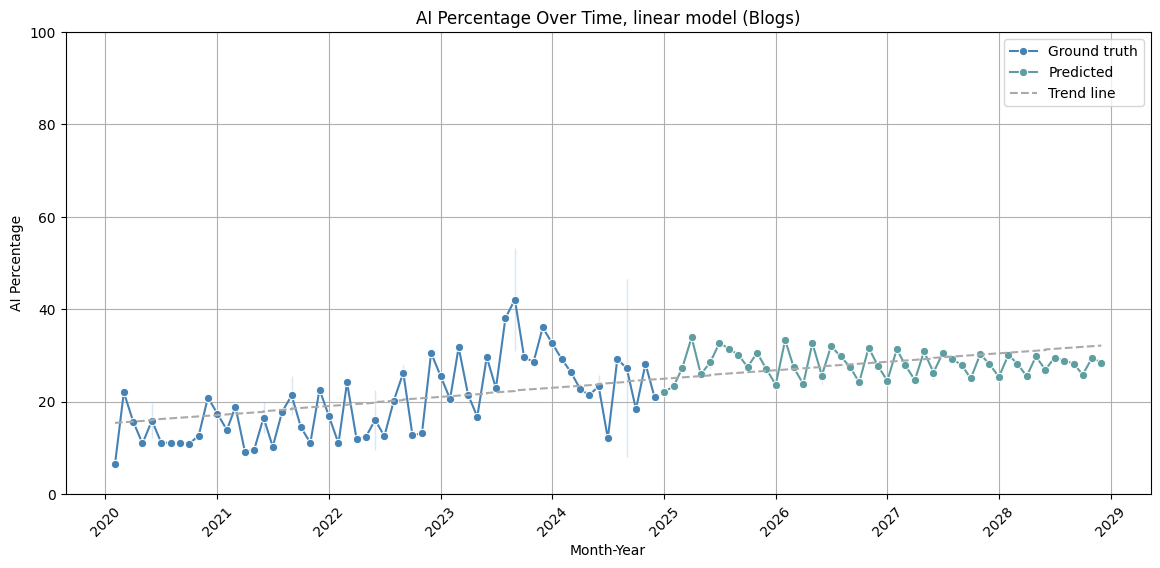

In [159]:
df_valid = combined_blogs[combined_blogs['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Trend line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, linear model (Blogs)')
plt.xticks(rotation=45)
plt.grid(True)
plt.ylim(0, 100)
plt.legend()
plt.show()


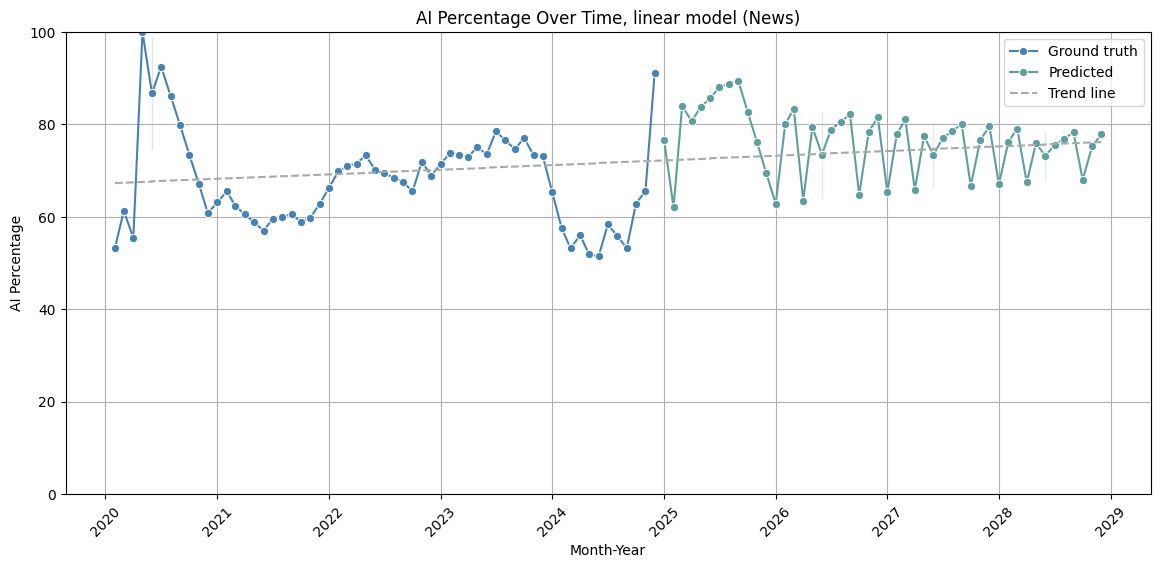

In [117]:
df_valid = combined_news[combined_news['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Best Fit Line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, linear model (News)')
plt.xticks(rotation=45)
plt.grid(True)
plt.ylim(0, 100)
plt.legend()
plt.show()


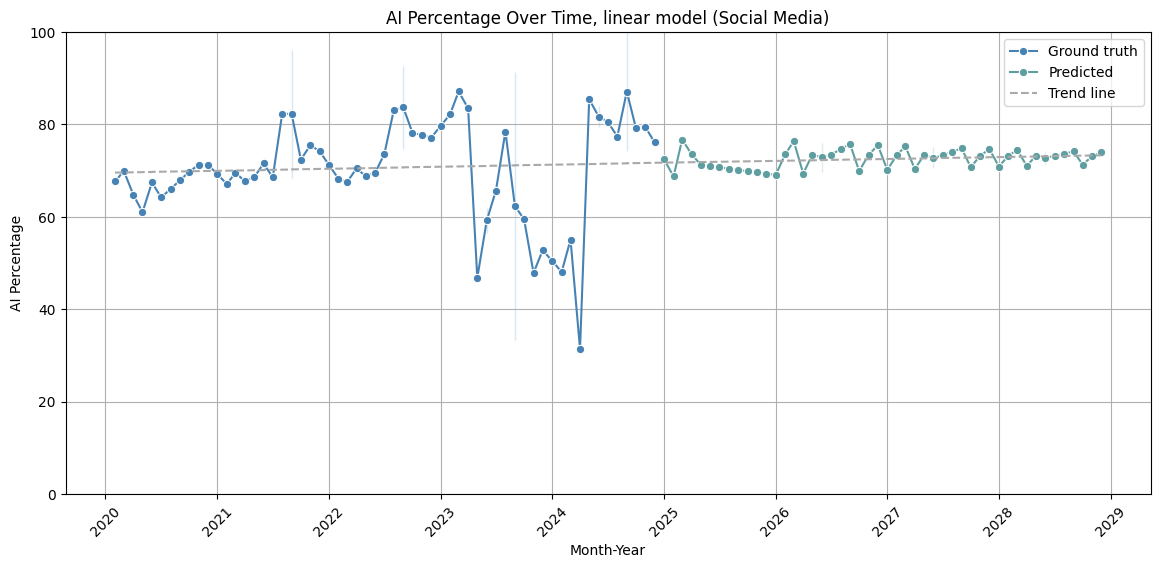

In [116]:
df_valid = combined_socmed[combined_socmed['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Trend line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, linear model (Social Media)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.show()


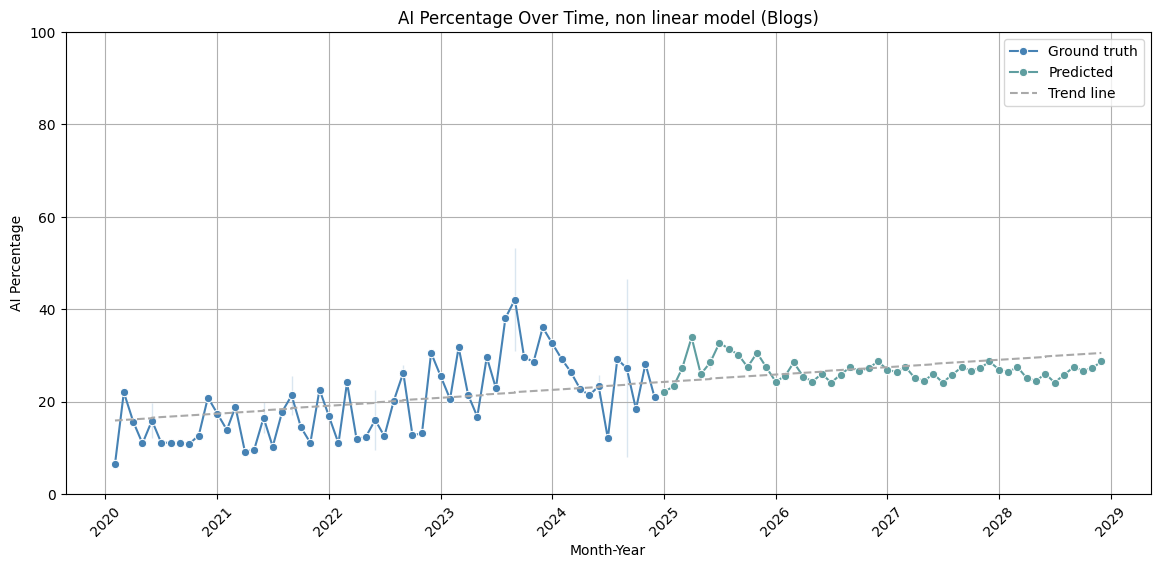

In [158]:
df_valid = nl_combined_blogs[nl_combined_blogs['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Trend line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, non linear model (Blogs)')
plt.xticks(rotation=45)
plt.grid(True)
plt.ylim(0, 100)
plt.legend()
plt.show()


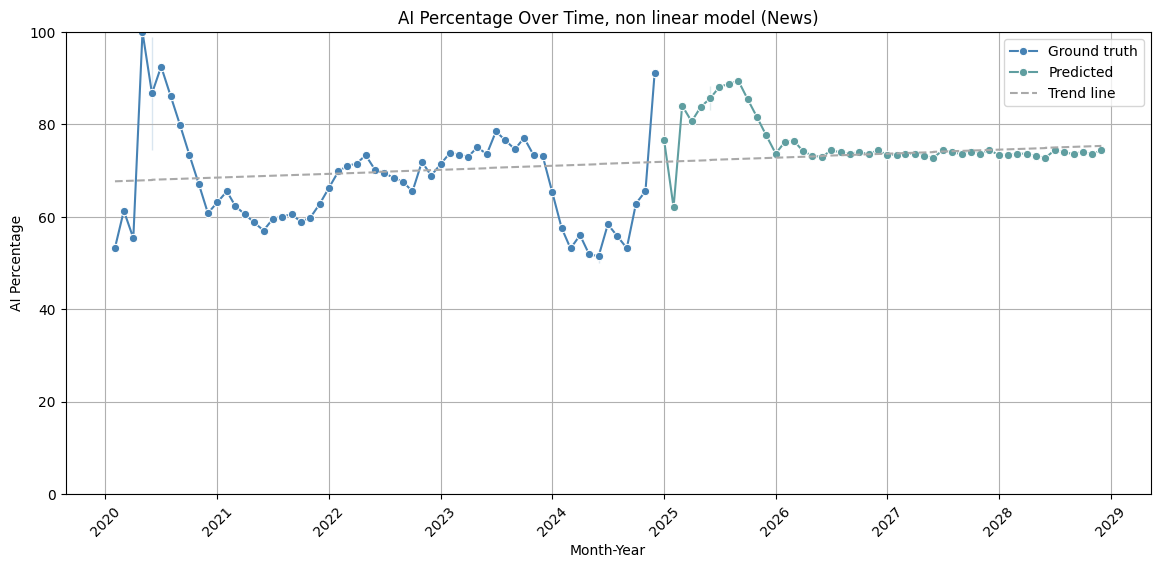

In [130]:
df_valid = nl_combined_news[nl_combined_news['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Trend line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, non linear model (News)')
plt.xticks(rotation=45)
plt.grid(True)
plt.ylim(0, 100)
plt.legend()
plt.show()


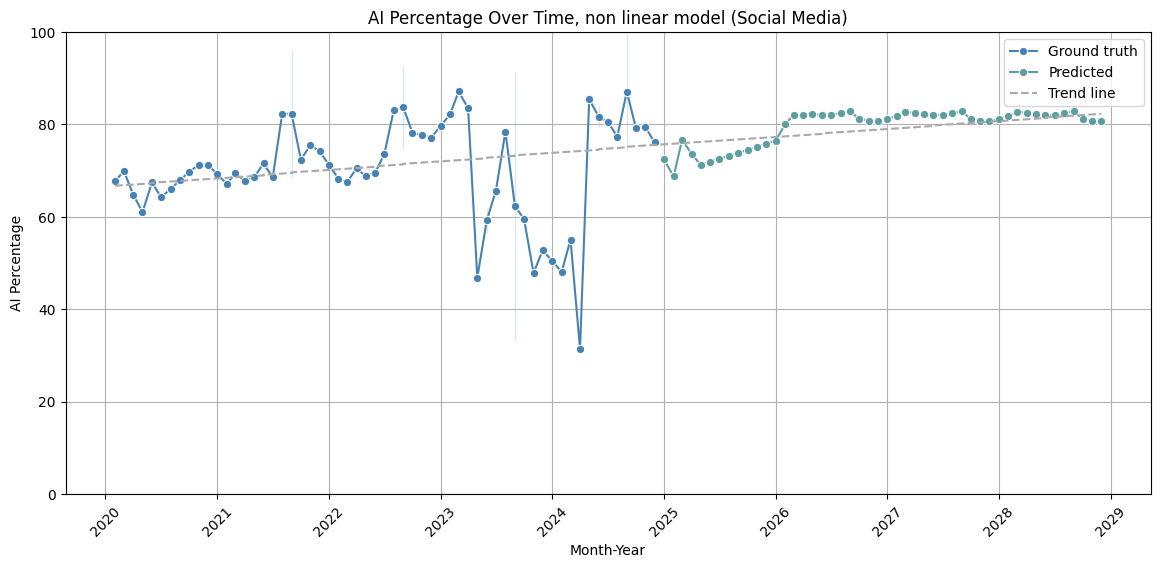

In [129]:
df_valid = nl_combined_socmed[nl_combined_socmed['month'].between(1,12)].copy()
df_valid['year_month'] = pd.to_datetime(df_valid[['year','month']].assign(DAY=1))

full_range = pd.DataFrame({'year_month': pd.date_range(df_valid['year_month'].min(),
                                                       df_valid['year_month'].max(),
                                                       freq='MS')})

df_full = full_range.merge(df_valid[['year_month','ai_percentage']], on='year_month', how='left')
df_full['ai_percentage'] = df_full['ai_percentage'].interpolate(method='linear')


df_full['color_group'] = np.where(df_full['year_month'].dt.year >= 2025, 'Predicted', 'Ground truth')

plt.figure(figsize=(14,6))

sns.lineplot(data=df_full, x='year_month', y='ai_percentage', hue='color_group', palette={'Ground truth':'steelblue', 'Predicted':'cadetblue'}, marker='o')


z = np.polyfit(df_full.index, df_full['ai_percentage'], 1)
p = np.poly1d(z)
plt.plot(df_full['year_month'], p(df_full.index),  linestyle='--', label='Trend line', color='darkgrey')

plt.xlabel('Month-Year')
plt.ylabel('AI Percentage')
plt.title('AI Percentage Over Time, non linear model (Social Media)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.show()


In [132]:
df_blogs_generated = pd.read_csv('blogs_generated_month.csv')

In [133]:
df_news_generated = pd.read_csv('df_news_generated.csv')

In [134]:
df_socmed_generated = pd.read_csv('socmed_generated_month.csv')

In [135]:
result_socmed = df_socmed_generated.groupby('source')['generated'].agg([
    ('0_count', lambda x: (x == 0).sum()),
    ('1_count', lambda x: (x == 1).sum()),
    ('pct_of_1', lambda x: (x == 1).mean() * 100)
]).reset_index()

result_socmed.columns = ['source', '0_count', '1_count', '% of 1/total']
result_socmed

,source,0_count,1_count,% of 1/total
0,facebook,50,136,73.118280
1,reddit,4798,13226,73.379938
2,twitter,791,44985,98.272020
3,youtube,23744,7361,23.665006


Text(0.5, 1.0, '% of AI in the social media dataset')

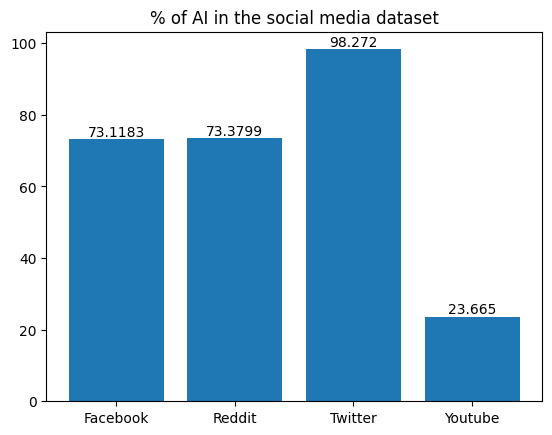

In [153]:
fig, ax = plt.subplots()

b = ax.bar(result_socmed['source'].map(lambda x: x[0].upper() +x[1:]).values, result_socmed['% of 1/total'])
ax.bar_label(b,label_type='edge')
ax.set_title('% of AI in the social media dataset')


In [136]:
result_blogs = df_blogs_generated.groupby('source')['generated'].agg([
    ('0_count', lambda x: (x == 0).sum()),
    ('1_count', lambda x: (x == 1).sum()),
    ('pct_of_1', lambda x: (x == 1).mean() * 100)
]).reset_index()

result_blogs.columns = ['source', '0_count', '1_count', '% of 1/total']
result_blogs

,source,0_count,1_count,% of 1/total
0,Gizmodo,8738,3341,27.659574
1,MLMastery,923,371,28.670788
2,Medium,3333,1701,33.790226
3,lifehacker,10558,1358,11.396442


Text(0.5, 1.0, '% of AI in the blogs dataset')

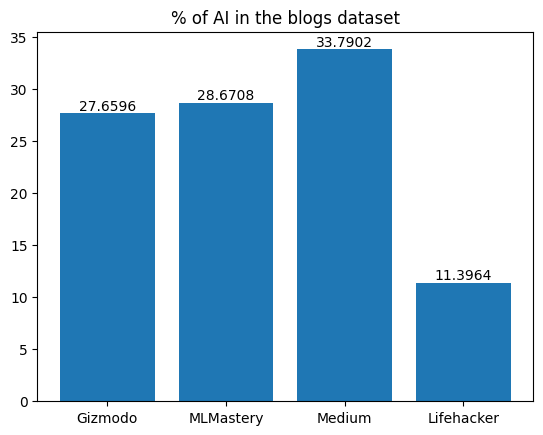

In [152]:
fig, ax = plt.subplots()

b = ax.bar(result_blogs['source'].map(lambda x: x[0].upper() +x[1:]).values, result_blogs['% of 1/total'])
ax.bar_label(b,label_type='edge')
ax.set_title('% of AI in the blogs dataset')


In [137]:
result_news = df_news_generated.groupby('publisher')['generated'].agg([
    ('0_count', lambda x: (x == 0).sum()),
    ('1_count', lambda x: (x == 1).sum()),
    ('pct_of_1', lambda x: (x == 1).mean() * 100)
]).reset_index()

result_news.columns = ['source', '0_count', '1_count', '% of 1/total']
result_news['total_count'] = result_news['0_count'] + result_news['1_count']
result_news = result_news[result_news['total_count'] >= 3000].copy()

In [138]:
result_news.sort_values('% of 1/total', ascending=False)

,source,0_count,1_count,% of 1/total,total_count
1486,GlobeNewswire,38,3867,99.026889,3905
1659,Zacks,412,4145,90.958964,4557
1592,Reuters,1067,3875,78.409551,4942
1699,['ACGLO'],1231,3395,73.389537,4626
1908,['AMZN'],1129,1879,62.466755,3008
1674,['AAPL'],3401,5280,60.822486,8681
1875,['AMD'],1542,2178,58.548387,3720
1607,Simply Wall St.,1446,1958,57.520564,3404
1618,Superstonk,1606,1446,47.378768,3052


Text(0.5, 1.0, '% of AI in the news dataset')

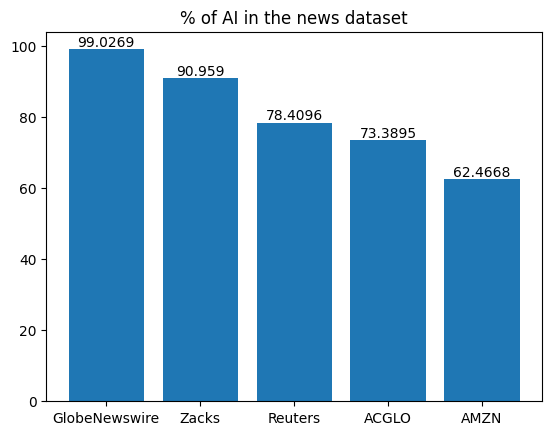

In [151]:
fig, ax = plt.subplots()

b = ax.bar(['GlobeNewswire','Zacks','Reuters','ACGLO','AMZN'], [99.026889,90.958964,78.409551,73.389537,62.466755])
ax.bar_label(b,label_type='edge')
ax.set_title('% of AI in the news dataset')
